In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath = '/content/drive/MyDrive/NEXIS_TeamAI_Healthcare/Data/insurance.csv'

## Import Libraries and Read Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(filepath)
print(df.head())
print(df.info())
print(df.describe())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000 

## Explore the Data

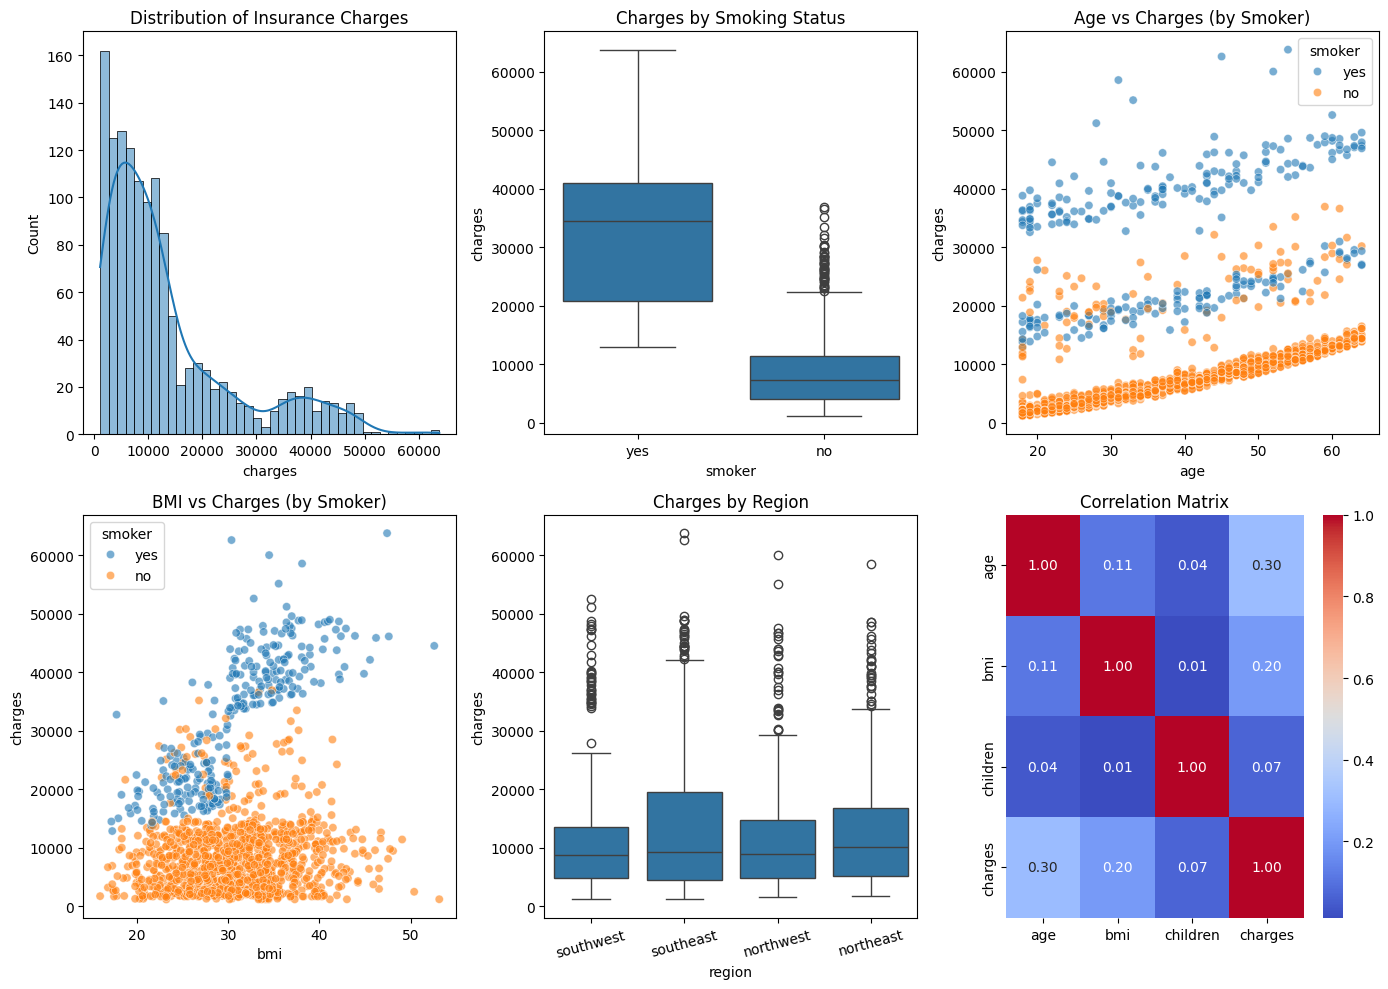

In [ ]:
# Distribution of charges
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
sns.histplot(df['charges'], kde=True, bins=40)
plt.title('Distribution of Insurance Charges')

plt.subplot(2, 3, 2)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')

plt.subplot(2, 3, 3)
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('Age vs Charges (by Smoker)')

plt.subplot(2, 3, 4)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('BMI vs Charges (by Smoker)')

plt.subplot(2, 3, 5)
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.xticks(rotation=15)

plt.subplot(2, 3, 6)
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

## Preprocessing the Data & Feature Engineering

In [ ]:
df_model = df.copy()

# Encode categoricals
le = LabelEncoder()
df_model['sex'] = le.fit_transform(df_model['sex'])          # female=0, male=1
df_model['smoker'] = le.fit_transform(df_model['smoker'])    # no=0, yes=1
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

# Engineer interaction features (strong predictors from EDA)
df_model['age_smoker'] = df_model['age'] * df_model['smoker']
df_model['bmi_smoker'] = df_model['bmi'] * df_model['smoker']
df_model['bmi_obese'] = (df_model['bmi'] >= 30).astype(int)
df_model['bmi_obese_smoker'] = df_model['bmi_obese'] * df_model['smoker']

# Log-transform target (charges are right-skewed)
df_model['log_charges'] = np.log1p(df_model['charges'])

print(df_model.head())
print("Features:", [c for c in df_model.columns if c not in ['charges', 'log_charges']])

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  age_smoker  bmi_smoker  bmi_obese  \
0             False              True          19        27.9          0   
1              True             False           0         0.0          1   
2              True             False           0         0.0          1   
3             False             False           0         0.0          0   
4             False             False           0         0.0          0   

   bmi_obese_smoker  log_charges  
0                 0     9.734236  
1                 0     7.453882  
2    

## Train & Test Data Split

In [ ]:
feature_cols = [c for c in df_model.columns if c not in ['charges', 'log_charges']]

X = df_model[feature_cols]
y = df_model['charges']          # raw charges
y_log = df_model['log_charges']  # log charges (for log-space models)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
_, _, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 1070, Test size: 268


## Model Training and Evaluation

In [ ]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, log_space=False):
    """Train, predict, and return evaluation metrics."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    if log_space:
        preds = np.expm1(preds)
        y_te = np.expm1(y_te)

    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  MAE:  ${mae:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    return {"name": name, "model": model, "mae": mae, "rmse": rmse, "r2": r2}

results = []

# Linear models (log-space)
results.append(evaluate_model("Linear Regression (log)", LinearRegression(),
    X_train_scaled, X_test_scaled, y_log_train, y_log_test, log_space=True))

results.append(evaluate_model("Ridge Regression (log)", Ridge(alpha=1.0),
    X_train_scaled, X_test_scaled, y_log_train, y_log_test, log_space=True))

results.append(evaluate_model("Lasso Regression (log)", Lasso(alpha=0.01),
    X_train_scaled, X_test_scaled, y_log_train, y_log_test, log_space=True))

# Tree-based models (raw target — don't need scaling, handle nonlinearity)
results.append(evaluate_model("Random Forest", RandomForestRegressor(n_estimators=200, random_state=42),
    X_train, X_test, y_train, y_test))

results.append(evaluate_model("Gradient Boosting", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42),
    X_train, X_test, y_train, y_test))

# Summary table
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in results])
print("\n\n", results_df.sort_values('r2', ascending=False).to_string(index=False))


  Linear Regression (log)
  MAE:  $2,278.13
  RMSE: $4,636.20
  R²:   0.8615

  Ridge Regression (log)
  MAE:  $2,268.86
  RMSE: $4,638.86
  R²:   0.8614

  Lasso Regression (log)
  MAE:  $2,168.21
  RMSE: $4,678.14
  R²:   0.8590

  Random Forest
  MAE:  $2,545.97
  RMSE: $4,583.27
  R²:   0.8647

  Gradient Boosting
  MAE:  $2,609.63
  RMSE: $4,748.52
  R²:   0.8548


                    name         mae        rmse       r2
          Random Forest 2545.965784 4583.271229 0.864692
Linear Regression (log) 2278.127707 4636.202772 0.861549
 Ridge Regression (log) 2268.857553 4638.855891 0.861390
 Lasso Regression (log) 2168.212019 4678.137737 0.859033
      Gradient Boosting 2609.634399 4748.515025 0.854760


## HyperParameter Tuning

In [ ]:
# Tune Gradient Boosting (typically best performer on this dataset)
param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [5, 10]
}

gb = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)
evaluate_model("Gradient Boosting (tuned)", best_model, X_train, X_test, y_train, y_test)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'learning_rate': 0.03, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 200}

  Gradient Boosting (tuned)
  MAE:  $2,470.59
  RMSE: $4,338.78
  R²:   0.8787


{'name': 'Gradient Boosting (tuned)',
 'model': GradientBoostingRegressor(learning_rate=0.03, min_samples_split=10,
                           n_estimators=200, random_state=42),
 'mae': 2470.593754725075,
 'rmse': np.float64(4338.775564211562),
 'r2': 0.8787431419521977}

## Feature Importance

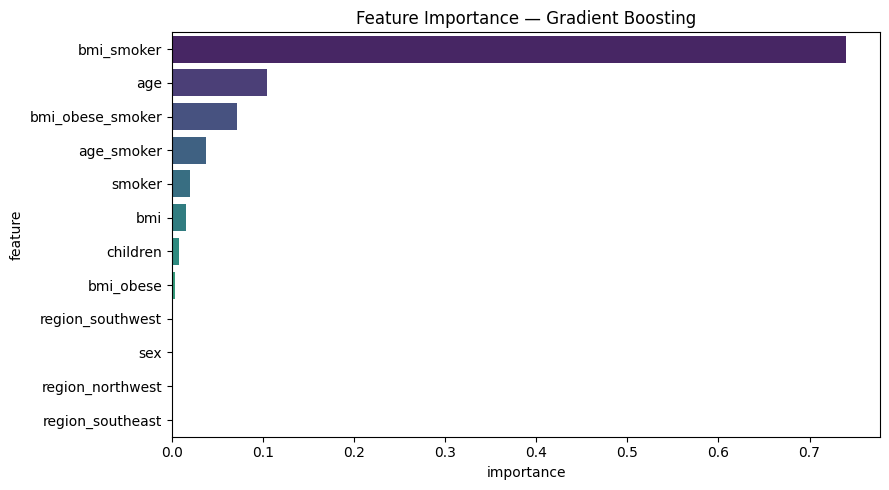

             feature  importance
9         bmi_smoker    0.740383
0                age    0.103839
11  bmi_obese_smoker    0.070925
8         age_smoker    0.037245
4             smoker    0.019589
2                bmi    0.015674
3           children    0.007128
10         bmi_obese    0.003173
7   region_southwest    0.001078
1                sex    0.000465
5   region_northwest    0.000259
6   region_southeast    0.000243


In [ ]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance — Gradient Boosting')
plt.tight_layout()
plt.show()

print(feature_importance)

## Prediction Function

In [ ]:
def predict_insurance_cost(model, scaler_obj=None, **kwargs):
    """
    Predict insurance cost for a given person profile.

    Parameters
    ----------
    model        : trained sklearn model
    scaler_obj   : StandardScaler if model was trained on scaled features, else None
    **kwargs     : person attributes
        age      (int)   : 18–64
        sex      (str)   : 'male' or 'female'
        bmi      (float) : body mass index
        children (int)   : number of dependents
        smoker   (str)   : 'yes' or 'no'
        region   (str)   : 'southwest', 'southeast', 'northwest', 'northeast'

    Returns
    -------
    float : predicted insurance charge in USD

    Example
    -------
    >>> predict_insurance_cost(best_model,
    ...     age=45, sex='female', bmi=32.5,
    ...     children=2, smoker='no', region='northeast')
    """
    age      = kwargs.get('age', 30)
    sex      = 1 if kwargs.get('sex', 'male') == 'male' else 0
    bmi      = kwargs.get('bmi', 25.0)
    children = kwargs.get('children', 0)
    smoker   = 1 if kwargs.get('smoker', 'no') == 'yes' else 0
    region   = kwargs.get('region', 'southeast')

    # One-hot for region (drop_first=True dropped 'northeast')
    region_nw = 1 if region == 'northwest' else 0
    region_se = 1 if region == 'southeast' else 0
    region_sw = 1 if region == 'southwest' else 0

    # Interaction features (must match training)
    age_smoker      = age * smoker
    bmi_smoker      = bmi * smoker
    bmi_obese       = 1 if bmi >= 30 else 0
    bmi_obese_smoker = bmi_obese * smoker

    features = np.array([[
        age, sex, bmi, children, smoker,
        region_nw, region_se, region_sw,
        age_smoker, bmi_smoker, bmi_obese, bmi_obese_smoker
    ]])

    if scaler_obj is not None:
        features = scaler_obj.transform(features)

    pred = model.predict(features)[0]
    return round(pred, 2)


# --- Example usage ---
sample_cost = predict_insurance_cost(
    best_model,          # tree-based — no scaler needed
    age=45,
    sex='female',
    bmi=29.0,
    children=2,
    smoker='no',
    region='northeast'
)
print(f"Predicted Insurance Cost: ${sample_cost:,.2f}")


# --- Batch prediction example (simulate multiple diagnoses/profiles) ---
profiles = [
    {"label": "Healthy Non-Smoker, 30yo",   "age": 30, "sex": "female", "bmi": 22.0, "children": 0, "smoker": "no",  "region": "northwest"},
    {"label": "Obese Non-Smoker, 45yo",     "age": 45, "sex": "male",   "bmi": 35.0, "children": 1, "smoker": "no",  "region": "southeast"},
    {"label": "Smoker, Normal BMI, 38yo",   "age": 38, "sex": "female", "bmi": 24.0, "children": 0, "smoker": "yes", "region": "southwest"},
    {"label": "Obese Smoker, 55yo",         "age": 55, "sex": "male",   "bmi": 40.0, "children": 3, "smoker": "yes", "region": "northeast"},
]

print("\n--- Batch Predictions ---")
for p in profiles:
    label = p.pop("label")
    cost = predict_insurance_cost(best_model, **p)
    print(f"  {label:40s}  →  ${cost:>10,.2f}")

Predicted Insurance Cost: $10,428.10

--- Batch Predictions ---
  Healthy Non-Smoker, 30yo                  →  $  5,112.45
  Obese Non-Smoker, 45yo                    →  $  9,347.06
  Smoker, Normal BMI, 38yo                  →  $ 18,900.86
  Obese Smoker, 55yo                        →  $ 47,058.58


## Actual vs Predicted Plot

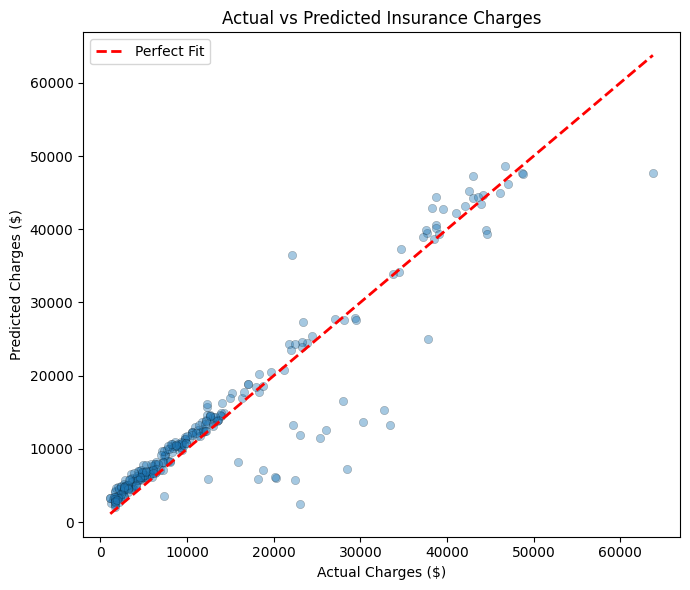

In [ ]:
y_pred_final = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_final, alpha=0.4, edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.tight_layout()
plt.show()